## This script will concatenate all the different tables from various sbs configurations and then merge the final table with existing good run list:
For additional information read `../scripts/epics/README.md` 

<span style="color:red">** [ATTENTION] Restart Kernel before re-running cell to avoid multiplication of same factor multiple times! **</span>

In [1]:
import numpy as np
import pandas as pd

/home/pdbforce/.local/lib/python3.8/site-packages/pandas/core/computation/expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.2' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
# Define the appropriate input variables
sbsconf = [4, 7, 11, 14, 8, 9]
target = 'LH2'
replay_pass = 1
prefix = '{}/avg_ebeam_prun_sbs'.format(target)

In [3]:
# Create a list with all relevant files to be concatenated
sheets = []    # list to store dfs per config 
ebeam_avg = [] # list to store avg. ebeam per config
ebeam_std = [] # list to store max std. value per config
for conf in sbsconf:
    filename = prefix + str(conf) + '_' + target + '.csv'
    tempdf = pd.DataFrame(pd.read_csv(filename))
    ebeam_avg.append(tempdf['ebeam_mean(GeV)'].mean())
    ebeam_std.append(tempdf['ebeam_std(GeV)'].max())
    sheets.append(tempdf)
# Creating a dict to hold avg. & max spread of ebeam per config to report
rdict = {'sobconfig':sbsconf, 'ebeam_avg(GeV)':ebeam_avg, 'max_spread(GeV)':ebeam_std}
rdf = pd.DataFrame.from_dict(rdict)

In [4]:
# concatenate tables from all different sbs configs
concatdf = pd.concat(sheets)
print(concatdf.head())
print(concatdf.shape)

   runnum  ebeam_mean(GeV)  ebeam_std(GeV)
0   11436         3.728110        0.000158
1   11500         3.728207        0.000137
2   11547         3.727972        0.000171
3   11548         3.727826        0.000073
4   11573         3.728115        0.000126
(176, 3)


### Important step - Taking into consideration the discrepancy between EPICS value and measured value
Doug measured hall A beam energy (4th pass) in 2016 and found that there is a discrepancy between the energy value he got and what HALLA_p EPICS PV was reading. HALLA_p value was a factor of **1.003** lower than the measured value. Here is a link to the log entry he had made after the measurement: https://logbooks.jlab.org/entry/3448841 . Since we haven't measure Hall A energy during GMn, we will be using the above mentioned factor for our analysis as well. **Here is a screenshot of the email he sent to Mark and myself summarizing his findings:**
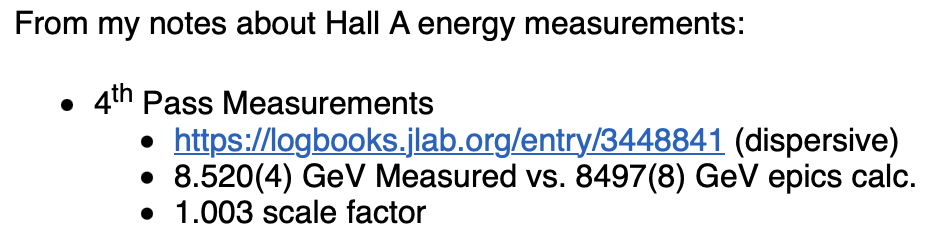

<span style="color:red">** [ATTENTION] Restart Kernel before re-running cell to avoid multiplication of same factor multiple times! **</span>

In [5]:
corr_fact = 1.003

In [6]:
# Multiply the energy_mean(GeV) and ebeam_std(GeV) columns with a factor of 1.003 to mitigate the discripancy between measured and observed values
concatdf['ebeam_mean(GeV)'] = concatdf['ebeam_mean(GeV)'] * corr_fact
concatdf['ebeam_std(GeV)'] = concatdf['ebeam_std(GeV)'] * corr_fact

In [7]:
print(concatdf.head())

   runnum  ebeam_mean(GeV)  ebeam_std(GeV)
0   11436         3.739294        0.000159
1   11500         3.739391        0.000137
2   11547         3.739156        0.000172
3   11548         3.739010        0.000074
4   11573         3.739300        0.000127


In [8]:
# Report corrected mean and maximum spread of beam energy per config
rdf['ebeam_avg(GeV)'] = (rdf['ebeam_avg(GeV)'] * corr_fact).apply(lambda x : round(x, 4))
rdf['max_spread(GeV)'] = (rdf['max_spread(GeV)'] * corr_fact).apply(lambda x : round(x, 4))

In [9]:
print("Target: {}".format(target))
rdf

Target: LH2


,sobconfig,ebeam_avg(GeV),max_spread(GeV)
0,4,3.7392,0.0002
1,7,7.9309,0.0009
2,11,9.8890,0.0006
3,14,5.9828,0.0005
4,8,5.9827,0.0011
5,9,4.0268,0.0007


### CAUTION!!
<span style="color:red">Execute the cells below only when super confident!</span>

In [10]:
# Read the master run spreadsheet to which we wanna merge our findings
#grunlname = 'good_runList_GMn_nTPE_{}_pass_{}.csv'.format(target, replay_pass)
#good_rListdf = pd.DataFrame(pd.read_csv(grunlname))

In [11]:
# Drop certain columns first (Useful in case of any edits)
#good_rListdf = good_rListdf.drop(columns=['ebeam_mean(GeV)', 'ebeam_std(GeV)'], axis=1)
#good_rListdf.head()

In [12]:
# Finally merge the new tables with good run list
#upd_grunLdf = pd.merge(good_rListdf, concatdf, on='runnum', how='outer')
#upd_grunLdf.to_csv(grunlname, index=False)

## Merging Scaler Tree Values

In [1]:
import numpy as np
import pandas as pd

/home/pdbforce/.local/lib/python3.8/site-packages/pandas/core/computation/expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.2' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
# Define the appropriate input variables
sbsconfch = [4, 7, 11, 14, 8, 9]
targetch = 'LD2'
replay_passch = 1

In [3]:
# Create a list with all relevant files to be concatenated
prefixch  = '{}/beamcharge_prun_SBS'.format(targetch)
sheetsch = []    # list to store dfs per config 
for conf in sbsconfch:
    filename = prefixch + str(conf) + '_' + targetch + '.csv'
    tempdf = pd.DataFrame(pd.read_csv(filename))
    sheetsch.append(tempdf)

In [4]:
# concatenate tables from all different sbs configs
concatdfch = pd.concat(sheetsch)
print(concatdfch.head())
print(concatdfch.shape)

   runnum  totcharge(C)
0   11449      0.002597
1   11451      0.002176
2   11452      0.008985
3   11456      0.007327
4   11493      0.002369
(568, 2)


#### Checking for NaNs
<span style="color:red">ATTENTION</span>

In [5]:
anyNaN = concatdfch.isnull().values.any()
#final_table_nz_nd.loc[pd.isna(final_table_nz_nd).any(1), :].index
#if (anyNaN == True): 
#    print('NaN exists! Replacing with 0')
#    concatdfch = concatdfch.fillna(0)
print(anyNaN)

False


In [6]:
# Report total beam charge per configuration
print("Target: {}".format(targetch))
for i in range(len(sbsconfch)):
    print('SBS{} : Total Charge {} C'.format(sbsconfch[i], round(sheetsch[i]['totcharge(C)'].sum(), 3)))

Target: LD2
SBS4 : Total Charge 0.079 C
SBS7 : Total Charge 0.535 C
SBS11 : Total Charge 9.589 C
SBS14 : Total Charge 1.516 C
SBS8 : Total Charge 1.194 C
SBS9 : Total Charge 2.554 C


### CAUTION!!
<span style="color:red">Execute the cells below only when super confident!</span>

In [7]:
# Read the master run spreadsheet to which we wanna merge our findings
#grunlnamech = 'good_runList_GMn_nTPE_{}_pass_{}.csv'.format(targetch, replay_passch)
#good_rListdfch = pd.DataFrame(pd.read_csv(grunlnamech))

In [8]:
# Drop certain columns first (Useful in case of any edits)
#good_rListdfch = good_rListdfch.drop(columns=['totcharge(C)'], axis=1)
#good_rListdfch.head()

In [9]:
# Finally merge the new tables with good run list
#upd_grunLdfch = pd.merge(good_rListdfch, concatdfch, on='runnum', how='outer')
#upd_grunLdfch.to_csv(grunlnamech, index=False)